# Générateur de données — Formation Causalité

Notebook de génération de données simulées illustrant quatre biais causaux classiques.
Tous les paramètres de simulation se trouvent dans la cellule **PARAMÈTRES** ci-dessous.

**Usage :** Kernel → Restart & Run All — aucune modification nécessaire hors de la cellule Paramètres.

---
Scénarios couverts :
- **Scénario 0** — Biais de petits nombres (variance binomiale)
- **Scénarios 1a/1b/1c** — Biais de sélection (confondant)
- **Scénario 2** — Surcontrôle sur un médiateur
- **Scénario 3** — Surcontrôle sur un collider

In [1]:
# ═══════════════════════════════════════════════════════════
# PARAMÈTRES — modifiez ici uniquement
# ═══════════════════════════════════════════════════════════

SEED        = 42
N_MAGASINS  = 200
T_MOIS      = 24

N_PETIT  = 30
N_MOYEN  = 150
N_GRAND  = 500

P_BASE_VISITE  = 0.25
EFFET_URBAIN   = 0.20
EFFET_EQUIPE   = 0.20
EFFET_SAISON   = {1: -0.01, 2: -0.01, 3: 0.0, 4: 0.01, 5: 0.02, 6: 0.02,
                   7: 0.02, 8: 0.01, 9: 0.0, 10: -0.01, 11: 0.01, 12: 0.02}

EFFET_PUB_VISITES = 0.10
EFFET_PUB_PANIER  = 0.10

MU_PANIER_BASE = 50.0
SIGMA_PANIER   = 15.0

P_PUB_BONNE_EQUIPE    = 0.70
P_PUB_MAUVAISE_EQUIPE = 0.30
P_PUB_URBAIN          = 0.65
P_PUB_RURAL           = 0.25
P_PUB_HAUTE_SAISON    = 0.70
P_PUB_BASSE_SAISON    = 0.30

PARAMS = {
    'seed': SEED,
    'n_magasins': N_MAGASINS,
    't_mois': T_MOIS,
    'n_petit': N_PETIT,
    'n_moyen': N_MOYEN,
    'n_grand': N_GRAND,
    'p_base_visite': P_BASE_VISITE,
    'effet_urbain': EFFET_URBAIN,
    'effet_equipe': EFFET_EQUIPE,
    'effet_saison': EFFET_SAISON,
    'effet_pub_visites': EFFET_PUB_VISITES,
    'effet_pub_panier': EFFET_PUB_PANIER,
    'mu_panier_base': MU_PANIER_BASE,
    'sigma_panier': SIGMA_PANIER,
    'p_pub_bonne_equipe': P_PUB_BONNE_EQUIPE,
    'p_pub_mauvaise_equipe': P_PUB_MAUVAISE_EQUIPE,
    'p_pub_urbain': P_PUB_URBAIN,
    'p_pub_rural': P_PUB_RURAL,
    'p_pub_haute_saison': P_PUB_HAUTE_SAISON,
    'p_pub_basse_saison': P_PUB_BASSE_SAISON,
}

In [2]:
# ═══════════════════════════════════════════════════════════
# IMPORTS ET CONFIGURATION
# ═══════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import networkx as nx
import statsmodels.formula.api as smf
import seaborn as sns
from pathlib import Path

# Configuration matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.size'] = 11

# RNG reproductible — seule source de hasard du notebook
# Passer rng en argument à chaque fonction qui en a besoin
# Ne jamais appeler np.random directement pour les tirages
rng = np.random.default_rng(SEED)

# Création automatique des dossiers d'export
Path('figures').mkdir(parents=True, exist_ok=True)
Path('data').mkdir(parents=True, exist_ok=True)

print(f"RNG initialisé avec SEED={SEED}")
print("Dossiers figures/ et data/ prets.")

RNG initialisé avec SEED=42
Dossiers figures/ et data/ prets.


---
## Générateur de panel partagé

Fonctions utilisées par tous les scénarios. `generate_base_panel` produit les caractéristiques structurelles. `compute_outcomes` calcule les variables d'outcome pour un DataFrame avec `pub` assigné.

In [3]:
def generate_base_panel(params, rng):
    """
    Génère le panel partagé N_magasins × T_mois.
    Retourne : DataFrame avec colonnes :
        magasin_id, taille, n_potentiel, urbain, qualite_equipe, mois, effet_saison_val
    NB : pas de colonnes pub, nb_visites, ventes, panier_moyen — assignées par chaque scénario.
    """
    n = params['n_magasins']
    t = params['t_mois']
    n_potentiel_map = {
        'petit': params['n_petit'],
        'moyen': params['n_moyen'],
        'grand': params['n_grand'],
    }
    # Caractéristiques fixes (vectorisé)
    magasins = pd.DataFrame({
        'magasin_id': range(n),
        'taille': rng.choice(['petit', 'moyen', 'grand'], size=n, p=[0.4, 0.4, 0.2]),
        'urbain': rng.integers(0, 2, size=n),   # binaire 0/1
        'qualite_equipe': rng.integers(0, 2, size=n),
    })
    magasins['n_potentiel'] = magasins['taille'].map(n_potentiel_map)
    # Panel magasin × mois (cross join pandas 2.x)
    mois_df = pd.DataFrame({'mois': range(1, t + 1)})
    base = magasins.merge(mois_df, how='cross')
    # Mapping cyclique mois → saison (supporte T_MOIS > 12)
    mois_saison = ((base['mois'] - 1) % 12) + 1
    base['effet_saison_val'] = mois_saison.map(params['effet_saison'])
    return base.reset_index(drop=True)


def compute_outcomes(df, params, rng):
    """
    Calcule p_visite, nb_visites, ventes, panier_moyen.
    Entrée : df avec colonnes taille, urbain, qualite_equipe, effet_saison_val, pub.
    p_visite est clippée à [0.01, 0.99] — OBLIGATOIRE avant rng.binomial().
    Approximation CLT pour ventes : ventes ~ Normal(nb_visites * mu, sqrt(nb_visites) * sigma).
    """
    p_visite = (
        params['p_base_visite']
        + params['effet_urbain'] * df['urbain']
        + params['effet_equipe'] * df['qualite_equipe']
        + df['effet_saison_val']
        + params['effet_pub_visites'] * df['pub']
    )
    p_visite = np.clip(p_visite, 0.01, 0.99)   # OBLIGATOIRE
    df = df.copy()
    df['p_visite'] = p_visite
    df['nb_visites'] = rng.binomial(df['n_potentiel'].values, p_visite.values)
    mu_panier = params['mu_panier_base'] * (1 + params['effet_pub_panier'] * df['pub'])
    df['ventes'] = (
        df['nb_visites'] * mu_panier
        + rng.normal(0, params['sigma_panier'], len(df)) * np.sqrt(df['nb_visites'])
    )
    df['panier_moyen'] = np.where(
        df['nb_visites'] > 0,
        df['ventes'] / df['nb_visites'],
        np.nan
    )
    return df

In [4]:
# ─────────────────────────────────────────────
# Génération du panel de base (pub=0 partout)
# ─────────────────────────────────────────────
base_df = generate_base_panel(PARAMS, rng)

# Ajouter pub=0 pour calculer les outcomes de référence
base_df['pub'] = 0
base_df = compute_outcomes(base_df, PARAMS, rng)
# Retirer pub du panel de base après calcul des outcomes (chaque scénario réassigne)
base_df = base_df.drop(columns=['pub'])

print(f"Panel de base : {len(base_df)} lignes × {len(base_df.columns)} colonnes")
print(f"Colonnes : {list(base_df.columns)}")
print(base_df.head(3))

# Export CSV
base_df.to_csv('data/base_panel.csv', index=False)
print("\nExporte : data/base_panel.csv")

Panel de base : 4800 lignes × 11 colonnes
Colonnes : ['magasin_id', 'taille', 'urbain', 'qualite_equipe', 'n_potentiel', 'mois', 'effet_saison_val', 'p_visite', 'nb_visites', 'ventes', 'panier_moyen']
   magasin_id taille  urbain  qualite_equipe  n_potentiel  mois  \
0           0  moyen       1               1          150     1   
1           0  moyen       1               1          150     2   
2           0  moyen       1               1          150     3   

   effet_saison_val  p_visite  nb_visites       ventes  panier_moyen  
0             -0.01      0.64          98  4896.920289     49.968574  
1             -0.01      0.64          90  4352.108485     48.356761  
2              0.00      0.65         100  4807.892384     48.078924  

Exporte : data/base_panel.csv


---
## Validation — Assertions automatiques

Vérifie que les paramètres par défaut produisent des données cohérentes. Cette cellule doit s'exécuter sans exception.

In [5]:
# 1. Cohérence paramétrique — p_visite ne peut dépasser 0.99
max_p = (PARAMS['p_base_visite'] + PARAMS['effet_urbain'] + PARAMS['effet_equipe']
         + max(PARAMS['effet_saison'].values()) + PARAMS['effet_pub_visites'])
assert max_p < 0.99, f"p_visite max cumulée ({max_p:.3f}) >= 0.99"

# 2. p_visite dans le DataFrame
assert base_df['p_visite'].between(0.01, 0.99).all(), "p_visite hors [0.01, 0.99]"

# 3. Pas de nb_visites = 0 (signalerait p_base trop faible)
assert base_df['nb_visites'].min() > 0, "nb_visites=0 détecté"

# 4. Variance ratio petit/grand > 2x (pédagogiquement visible)
std_by_taille = base_df.groupby('taille')['panier_moyen'].std()
ratio = std_by_taille['petit'] / std_by_taille['grand']
assert ratio > 2.0, f"Variance ratio petit/grand = {ratio:.1f}x < 2.0 cible"

# 5. pub absent de base_df
assert 'pub' not in base_df.columns, "pub ne doit pas etre dans base_df"

print(f"Assertions OK — max p_visite cumulee: {max_p:.3f}, variance ratio: {ratio:.1f}x")

Assertions OK — max p_visite cumulee: 0.770, variance ratio: 4.0x


---
## Scénario 0 — Biais de petits nombres

Les petits magasins dominent les extrêmes de distribution du `panier_moyen` en raison de la variance binomiale : avec peu de clients potentiels, la loi des grands nombres n'a pas le temps de lisser les fluctuations.

In [6]:
# ─────────────────────────────────────────────
# Scénario 0 — Agrégation par magasin
# ─────────────────────────────────────────────
# Agrégation base_df → 200 points (un par magasin)
# 'taille' dans le groupby est obligatoire pour conserver la colonne dans l'agrégat
agg_sc0 = base_df.groupby(['magasin_id', 'taille']).agg(
    n_potentiel=('n_potentiel', 'first'),
    nb_visites_moy=('nb_visites', 'mean'),
    panier_moyen_moy=('panier_moyen', 'mean'),
    panier_moyen_std=('panier_moyen', 'std'),
).reset_index()

# Export CSV scénario 0
agg_sc0.to_csv('data/sc0_biais_petits_nombres.csv', index=False)
print(f'Scénario 0 : {len(agg_sc0)} magasins agrégés')
print(agg_sc0.groupby('taille').size().to_string())

Scénario 0 : 200 magasins agrégés
taille
grand    35
moyen    86
petit    79


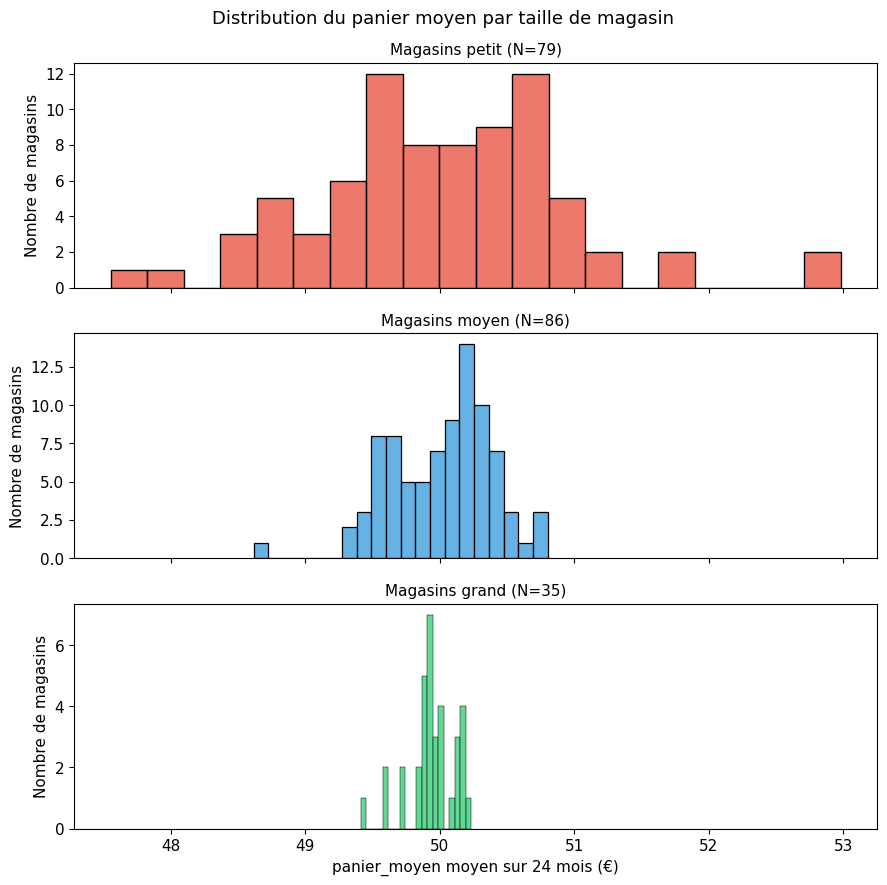

In [7]:
# ─────────────────────────────────────────────
# Figure 1 — Distribution du panier moyen par taille de magasin
# ─────────────────────────────────────────────
colors_sc0 = {'petit': '#e74c3c', 'moyen': '#3498db', 'grand': '#2ecc71'}
tailles_ordre = ['petit', 'moyen', 'grand']

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
for ax, taille in zip(axes, tailles_ordre):
    subset = agg_sc0[agg_sc0['taille'] == taille]
    sns.histplot(data=subset, x='panier_moyen_moy', ax=ax,
                 color=colors_sc0[taille], bins=20)
    ax.set_title(f'Magasins {taille} (N={len(subset)})', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Nombre de magasins')

axes[-1].set_xlabel('panier_moyen moyen sur 24 mois (€)')
fig.suptitle('Distribution du panier moyen par taille de magasin', fontsize=13)
plt.tight_layout()
fig.savefig('figures/sc0_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

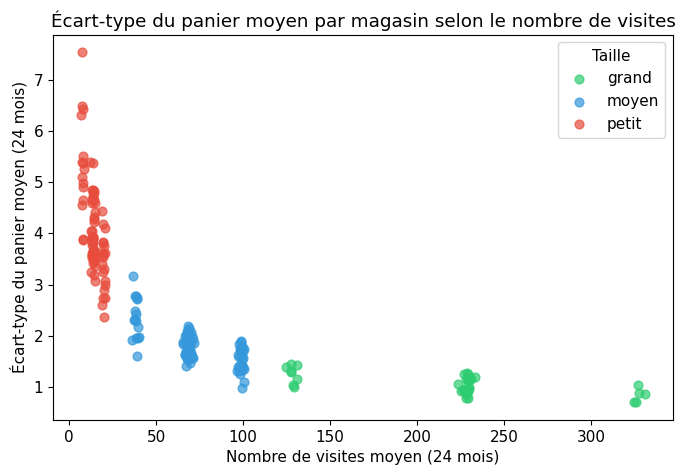

In [8]:
# ─────────────────────────────────────────────
# Figure 2 — Variance du panier moyen vs affluence
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for taille, grp in agg_sc0.groupby('taille'):
    ax.scatter(grp['nb_visites_moy'], grp['panier_moyen_std'],
               color=colors_sc0[taille], label=taille, alpha=0.7, s=40)

ax.set_xlabel('Nombre de visites moyen (24 mois)')
ax.set_ylabel('Écart-type du panier moyen (24 mois)')
ax.set_title('Écart-type du panier moyen par magasin selon le nombre de visites')
ax.legend(title='Taille')
fig.savefig('figures/sc0_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

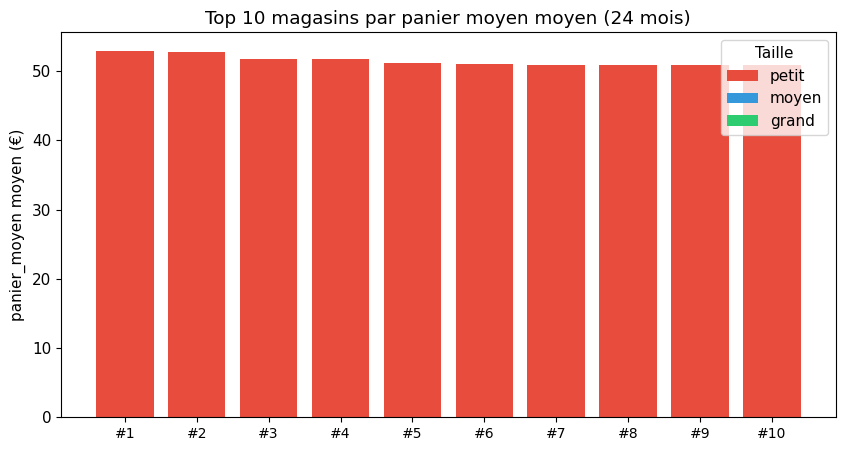

Top 10 : 10/10 petits magasins (100%)


In [9]:
# ─────────────────────────────────────────────
# Figure 3 — Top 10 magasins par panier moyen (analyse naïve)
# ─────────────────────────────────────────────
top10 = agg_sc0.nlargest(10, 'panier_moyen_moy').reset_index(drop=True)
bar_colors = [colors_sc0[t] for t in top10['taille']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(top10)), top10['panier_moyen_moy'], color=bar_colors)
ax.set_xticks(range(len(top10)))
ax.set_xticklabels([f"#{i+1}" for i in range(len(top10))], fontsize=10)
ax.set_ylabel('panier_moyen moyen (€)')
ax.set_title('Top 10 magasins par panier moyen moyen (24 mois)')

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(facecolor=colors_sc0[t], label=t) for t in tailles_ordre],
    title='Taille'
)
fig.savefig('figures/sc0_top10.png', dpi=150, bbox_inches='tight')
plt.show()

n_petits_top10 = (top10['taille'] == 'petit').sum()
print(f"Top 10 : {n_petits_top10}/10 petits magasins ({100*n_petits_top10//10}%)")

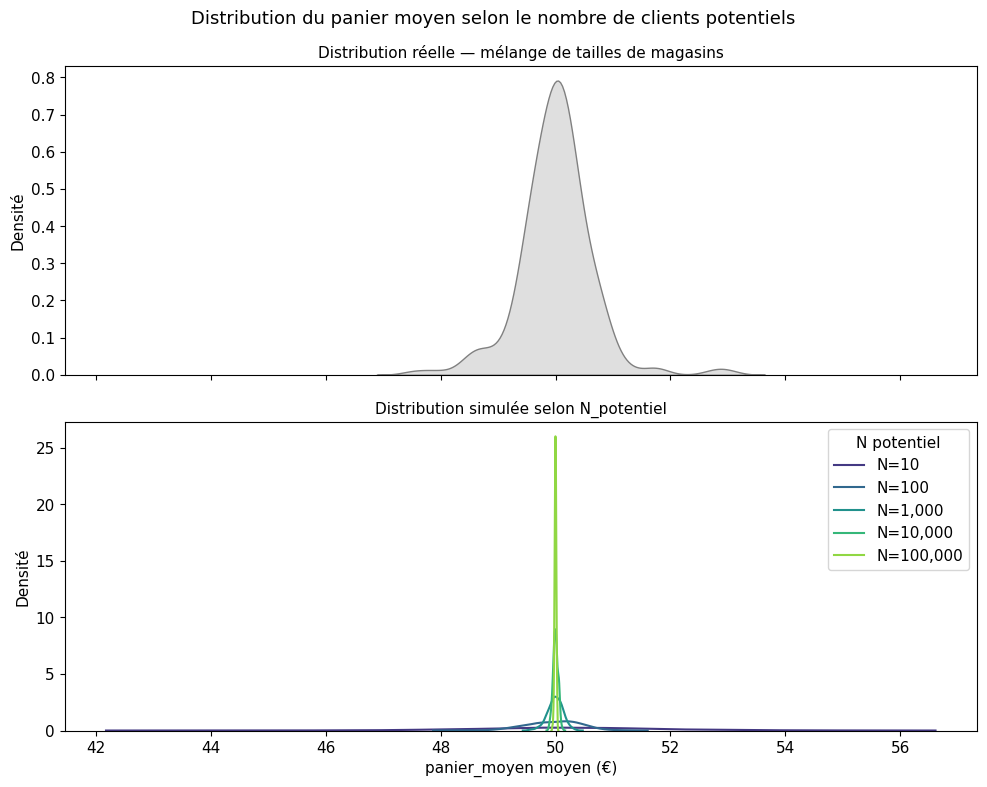

In [10]:
# ─────────────────────────────────────────────
# Figure 4 — Mécanisme : loi des grands nombres
# ─────────────────────────────────────────────
# CRITIQUE : rng_fig4 LOCAL — ne jamais utiliser le rng global ici
# (cela décalerait l'état du générateur pour les scénarios 1-3)
rng_fig4 = np.random.default_rng(SEED + 4)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Rang 1 (haut) : KDE de la distribution réelle (mélange petit/moyen/grand)
sns.kdeplot(data=agg_sc0['panier_moyen_moy'], ax=axes[0],
            fill=True, color='gray', label='Données réelles')
axes[0].set_title('Distribution réelle — mélange de tailles de magasins', fontsize=11)
axes[0].set_ylabel('Densité')
axes[0].set_xlabel('')

# Rang 2 (bas) : KDE overlay pour N = 10, 100, 1000, 10000, 100000
N_values = [10, 100, 1000, 10000, 100000]
palette_fig4 = sns.color_palette('viridis', len(N_values))

for N, color in zip(N_values, palette_fig4):
    params_sim = {**PARAMS, 'n_petit': N, 'n_moyen': N, 'n_grand': N}
    sim_df = generate_base_panel(params_sim, rng_fig4)
    sim_df['pub'] = 0
    sim_df = compute_outcomes(sim_df, params_sim, rng_fig4)
    agg_sim = sim_df.groupby('magasin_id')['panier_moyen'].mean()
    sns.kdeplot(data=agg_sim.dropna(), ax=axes[1],
                label=f'N={N:,}', color=color, warn_singular=False)

axes[1].set_title('Distribution simulée selon N_potentiel', fontsize=11)
axes[1].set_xlabel('panier_moyen moyen (€)')
axes[1].set_ylabel('Densité')
axes[1].legend(title='N potentiel')

fig.suptitle('Distribution du panier moyen selon le nombre de clients potentiels',
             fontsize=13)
plt.tight_layout()
fig.savefig('figures/sc0_loi_grands_nombres.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Pattern DAG

Démonstration du pattern NetworkX utilisé dans tous les scénarios. Layout fixe via `pos` dict — jamais `spring_layout`.

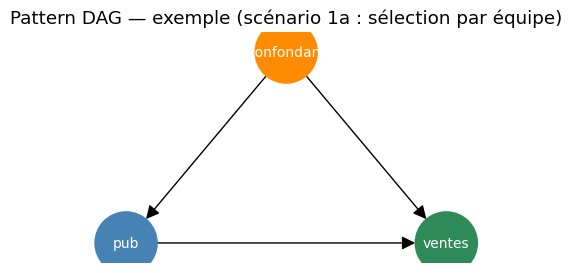

In [11]:
# Démonstration du pattern DAG utilisé dans tous les scénarios
G = nx.DiGraph()
G.add_edges_from([
    ('pub', 'ventes'),
    ('confondant', 'pub'),
    ('confondant', 'ventes'),
])
# FIXE — layout fixe via pos dict uniquement
pos = {'pub': (0, 0), 'ventes': (2, 0), 'confondant': (1, 1)}

fig, ax = plt.subplots(figsize=(5, 3))
nx.draw_networkx(G, pos, ax=ax,
                 node_color=['steelblue', 'seagreen', 'darkorange'],
                 node_size=2000, font_size=10, font_color='white',
                 arrows=True, arrowsize=20)
ax.axis('off')
ax.set_title('Pattern DAG — exemple (scénario 1a : sélection par équipe)')
fig.savefig('figures/dag_pattern_demo.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Scénario 1a — Biais de sélection par qualité d'équipe

Le confondant `qualite_equipe` détermine à la fois la probabilité de recevoir la pub et le niveau des ventes. Comparer naïvement magasins traités et non traités surestime l'effet de la pub.

In [12]:
# ─────────────────────────────────────────────
# Scénario 1a — Sélection par qualité d'équipe
# Confondant : qualite_equipe (binaire)
# Assignation pub : niveau magasin (constant sur 24 mois)
# ─────────────────────────────────────────────

rng_sc1a = np.random.default_rng(SEED + 10)

# Assignation pub au niveau magasin
stores_1a = base_df[['magasin_id', 'qualite_equipe']].drop_duplicates('magasin_id').copy()
probs_1a = np.where(
    stores_1a['qualite_equipe'] == 1,
    P_PUB_BONNE_EQUIPE,
    P_PUB_MAUVAISE_EQUIPE
)
stores_1a['pub'] = rng_sc1a.binomial(1, probs_1a)

# Merge vers le panel complet + calcul des outcomes observés
df_sc1a = base_df.merge(stores_1a[['magasin_id', 'pub']], on='magasin_id')
df_sc1a = compute_outcomes(df_sc1a, PARAMS, rng_sc1a)

# Calcul ATT contrefactuel (rng dédié pour isoler la reproductibilité)
treated_ids_1a = stores_1a[stores_1a['pub'] == 1]['magasin_id'].values
df_treated_1a = df_sc1a[df_sc1a['magasin_id'].isin(treated_ids_1a)].copy()
rng_cf_1a = np.random.default_rng(SEED + 11)
df_cf_1a = df_treated_1a.copy()
df_cf_1a['pub'] = 0
df_cf_1a = compute_outcomes(df_cf_1a, PARAMS, rng_cf_1a)
att_1a = (df_treated_1a['ventes'].values - df_cf_1a['ventes'].values).mean()

# OLS naïf : contrôle la saisonnalité mais PAS le confondant qualite_equipe
model_naive_1a = smf.ols('ventes ~ pub + C(mois)', data=df_sc1a).fit()
# OLS ajusté : contrôle qualite_equipe et la saisonnalité
model_adj_1a   = smf.ols('ventes ~ pub + qualite_equipe + C(mois)', data=df_sc1a).fit()

# Export CSV
df_sc1a.to_csv('data/sc1a_selection_qualite.csv', index=False)
print(f"Sc1a — Traités: {len(treated_ids_1a)}/200 magasins")
print(f"Sc1a — ATT: {att_1a:.1f} €  |  OLS naïf: {model_naive_1a.params['pub']:.1f} €  |  OLS ajusté: {model_adj_1a.params['pub']:.1f} €")

Sc1a — Traités: 102/200 magasins
Sc1a — ATT: 1226.3 €  |  OLS naïf: 1427.0 €  |  OLS ajusté: 725.1 €


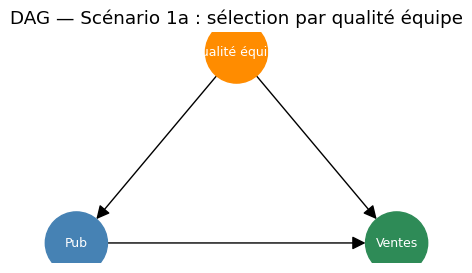

In [13]:
# ─────────────────────────────────────────────
# Figure DAG — Scénario 1a
# ─────────────────────────────────────────────

G_1a = nx.DiGraph()
G_1a.add_edges_from([
    ('Qualité équipe', 'Pub'),
    ('Qualité équipe', 'Ventes'),
    ('Pub', 'Ventes'),
])
pos_1a = {'Pub': (0, 0), 'Ventes': (2, 0), 'Qualité équipe': (1, 1)}

color_map_1a = {'Pub': 'steelblue', 'Ventes': 'seagreen', 'Qualité équipe': 'darkorange'}
node_colors_1a = [color_map_1a[n] for n in G_1a.nodes()]

fig, ax = plt.subplots(figsize=(5, 3))
nx.draw_networkx(G_1a, pos_1a, ax=ax,
                 node_color=node_colors_1a,
                 node_size=2000, font_size=9, font_color='white',
                 arrows=True, arrowsize=20)
ax.axis('off')
ax.set_title('DAG — Scénario 1a : sélection par qualité équipe')
fig.savefig('figures/sc1a_dag.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Scénario 1b — Biais de sélection par localisation

Le confondant `urbain` détermine à la fois la probabilité de recevoir la pub et le niveau des ventes. Comparer naïvement les magasins traités et non traités surestime l'effet de la pub.

In [14]:
# ─────────────────────────────────────────────
# Scénario 1b — Sélection par localisation urbain/rural
# Confondant : urbain (binaire)
# Assignation pub : niveau magasin (constant sur 24 mois)
# ─────────────────────────────────────────────

rng_sc1b = np.random.default_rng(SEED + 20)

# Assignation pub au niveau magasin
stores_1b = base_df[['magasin_id', 'urbain']].drop_duplicates('magasin_id').copy()
probs_1b = np.where(
    stores_1b['urbain'] == 1,
    P_PUB_URBAIN,
    P_PUB_RURAL
)
stores_1b['pub'] = rng_sc1b.binomial(1, probs_1b)

# Merge vers le panel complet + calcul des outcomes observés
df_sc1b = base_df.merge(stores_1b[['magasin_id', 'pub']], on='magasin_id')
df_sc1b = compute_outcomes(df_sc1b, PARAMS, rng_sc1b)

# Calcul ATT contrefactuel
treated_ids_1b = stores_1b[stores_1b['pub'] == 1]['magasin_id'].values
df_treated_1b = df_sc1b[df_sc1b['magasin_id'].isin(treated_ids_1b)].copy()
rng_cf_1b = np.random.default_rng(SEED + 21)
df_cf_1b = df_treated_1b.copy()
df_cf_1b['pub'] = 0
df_cf_1b = compute_outcomes(df_cf_1b, PARAMS, rng_cf_1b)
att_1b = (df_treated_1b['ventes'].values - df_cf_1b['ventes'].values).mean()

# OLS naïf : contrôle la saisonnalité mais PAS le confondant urbain
model_naive_1b = smf.ols('ventes ~ pub + C(mois)', data=df_sc1b).fit()
# OLS ajusté : contrôle urbain et la saisonnalité
model_adj_1b   = smf.ols('ventes ~ pub + urbain + C(mois)', data=df_sc1b).fit()

# Export CSV
df_sc1b.to_csv('data/sc1b_selection_urbain.csv', index=False)
print(f"Sc1b — Traités: {len(treated_ids_1b)}/200 magasins")
print(f"Sc1b — ATT: {att_1b:.1f} €  |  OLS naïf: {model_naive_1b.params['pub']:.1f} €  |  OLS ajusté: {model_adj_1b.params['pub']:.1f} €")

Sc1b — Traités: 86/200 magasins
Sc1b — ATT: 1267.9 €  |  OLS naïf: 1354.8 €  |  OLS ajusté: 1034.3 €


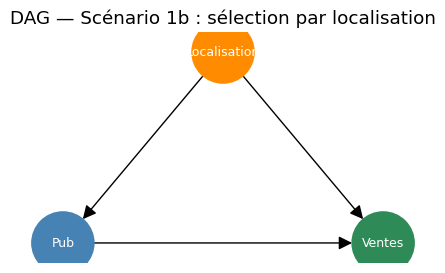

In [15]:
# ─────────────────────────────────────────────
# Figure DAG — Scénario 1b
# ─────────────────────────────────────────────

G_1b = nx.DiGraph()
G_1b.add_edges_from([
    ('Localisation', 'Pub'),
    ('Localisation', 'Ventes'),
    ('Pub', 'Ventes'),
])
pos_1b = {'Pub': (0, 0), 'Ventes': (2, 0), 'Localisation': (1, 1)}

color_map_1b = {'Pub': 'steelblue', 'Ventes': 'seagreen', 'Localisation': 'darkorange'}
node_colors_1b = [color_map_1b[n] for n in G_1b.nodes()]

fig, ax = plt.subplots(figsize=(5, 3))
nx.draw_networkx(G_1b, pos_1b, ax=ax,
                 node_color=node_colors_1b,
                 node_size=2000, font_size=9, font_color='white',
                 arrows=True, arrowsize=20)
ax.axis('off')
ax.set_title('DAG — Scénario 1b : sélection par localisation')
fig.savefig('figures/sc1b_dag.png', dpi=150, bbox_inches='tight')
plt.show()

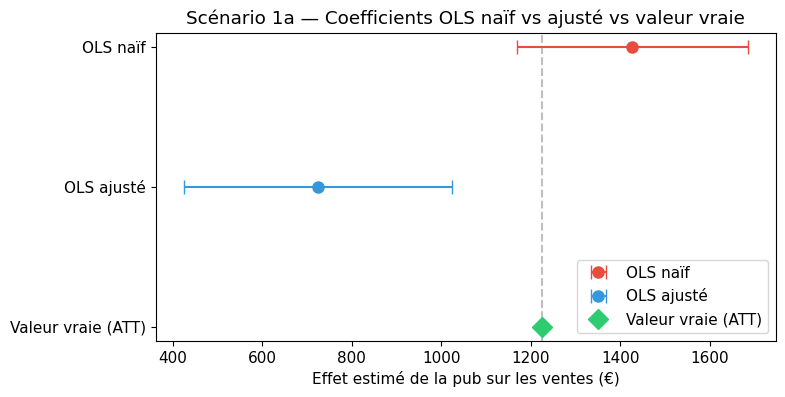

In [16]:
# ─────────────────────────────────────────────
# Figure coefficient plot — Scénario 1a
# 3 points : OLS naïf, OLS ajusté, ATT (valeur vraie)
# ─────────────────────────────────────────────

coef_naive_1a = model_naive_1a.params['pub']
ci_naive_1a   = model_naive_1a.conf_int()
lower_naive_1a = ci_naive_1a.loc['pub', 0]
upper_naive_1a = ci_naive_1a.loc['pub', 1]

coef_adj_1a = model_adj_1a.params['pub']
ci_adj_1a   = model_adj_1a.conf_int()
lower_adj_1a = ci_adj_1a.loc['pub', 0]
upper_adj_1a = ci_adj_1a.loc['pub', 1]

# xerr = distances positives par rapport au centre (pas les bornes absolues)
xerr_naive_1a = [[coef_naive_1a - lower_naive_1a], [upper_naive_1a - coef_naive_1a]]
xerr_adj_1a   = [[coef_adj_1a   - lower_adj_1a],   [upper_adj_1a   - coef_adj_1a]]

estimators_1a = ['OLS naïf', 'OLS ajusté', 'Valeur vraie (ATT)']
y_pos_1a = [2, 1, 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(coef_naive_1a, 2, xerr=xerr_naive_1a, fmt='o', capsize=5,
            color='#e74c3c', label='OLS naïf', markersize=8)
ax.errorbar(coef_adj_1a, 1, xerr=xerr_adj_1a, fmt='o', capsize=5,
            color='#3498db', label='OLS ajusté', markersize=8)
ax.errorbar(att_1a, 0, fmt='D', color='#2ecc71', label='Valeur vraie (ATT)', markersize=10)
ax.axvline(x=att_1a, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks(y_pos_1a)
ax.set_yticklabels(estimators_1a)
ax.set_xlabel('Effet estimé de la pub sur les ventes (€)')
ax.set_title('Scénario 1a — Coefficients OLS naïf vs ajusté vs valeur vraie')
ax.legend(loc='lower right')
fig.savefig('figures/sc1a_coeff.png', dpi=150, bbox_inches='tight')
plt.show()

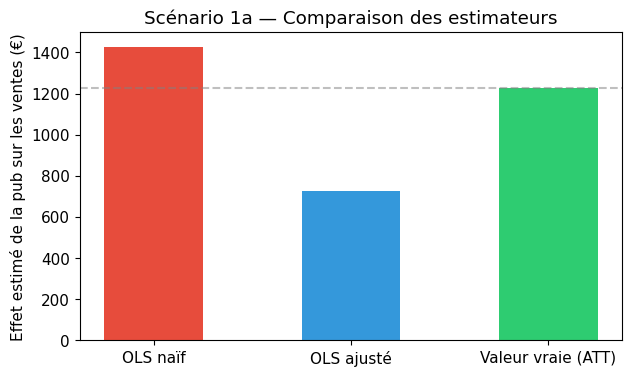

In [17]:
# ─────────────────────────────────────────────
# Figure bar chart — Scénario 1a
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 4))
labels_1a = ['OLS naïf', 'OLS ajusté', 'Valeur vraie (ATT)']
values_1a = [coef_naive_1a, coef_adj_1a, att_1a]
colors_est = ['#e74c3c', '#3498db', '#2ecc71']

ax.bar(range(len(labels_1a)), values_1a, color=colors_est, width=0.5)
ax.set_xticks(range(len(labels_1a)))
ax.set_xticklabels(labels_1a)
ax.set_ylabel('Effet estimé de la pub sur les ventes (€)')
ax.set_title('Scénario 1a — Comparaison des estimateurs')
ax.axhline(y=att_1a, color='gray', linestyle='--', alpha=0.5)
fig.savefig('figures/sc1a_bar.png', dpi=150, bbox_inches='tight')
plt.show()

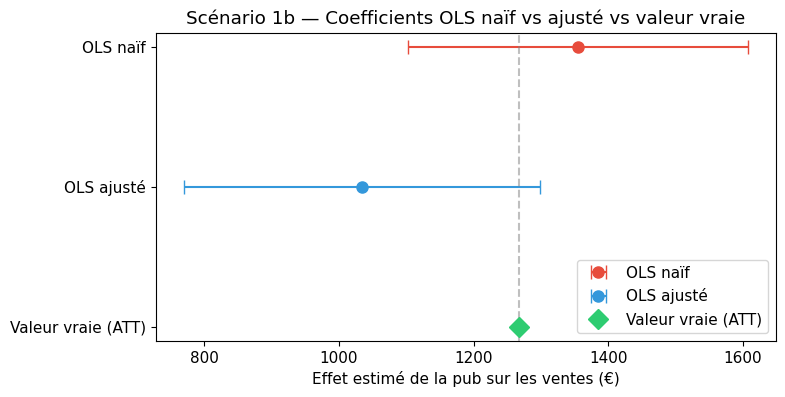

In [18]:
# ─────────────────────────────────────────────
# Figure coefficient plot — Scénario 1b
# ─────────────────────────────────────────────

coef_naive_1b = model_naive_1b.params['pub']
ci_naive_1b   = model_naive_1b.conf_int()
lower_naive_1b = ci_naive_1b.loc['pub', 0]
upper_naive_1b = ci_naive_1b.loc['pub', 1]

coef_adj_1b = model_adj_1b.params['pub']
ci_adj_1b   = model_adj_1b.conf_int()
lower_adj_1b = ci_adj_1b.loc['pub', 0]
upper_adj_1b = ci_adj_1b.loc['pub', 1]

xerr_naive_1b = [[coef_naive_1b - lower_naive_1b], [upper_naive_1b - coef_naive_1b]]
xerr_adj_1b   = [[coef_adj_1b   - lower_adj_1b],   [upper_adj_1b   - coef_adj_1b]]

colors_est = ['#e74c3c', '#3498db', '#2ecc71']

estimators_1b = ['OLS naïf', 'OLS ajusté', 'Valeur vraie (ATT)']
y_pos_1b = [2, 1, 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(coef_naive_1b, 2, xerr=xerr_naive_1b, fmt='o', capsize=5,
            color='#e74c3c', label='OLS naïf', markersize=8)
ax.errorbar(coef_adj_1b, 1, xerr=xerr_adj_1b, fmt='o', capsize=5,
            color='#3498db', label='OLS ajusté', markersize=8)
ax.errorbar(att_1b, 0, fmt='D', color='#2ecc71', label='Valeur vraie (ATT)', markersize=10)
ax.axvline(x=att_1b, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks(y_pos_1b)
ax.set_yticklabels(estimators_1b)
ax.set_xlabel('Effet estimé de la pub sur les ventes (€)')
ax.set_title('Scénario 1b — Coefficients OLS naïf vs ajusté vs valeur vraie')
ax.legend(loc='lower right')
fig.savefig('figures/sc1b_coeff.png', dpi=150, bbox_inches='tight')
plt.show()

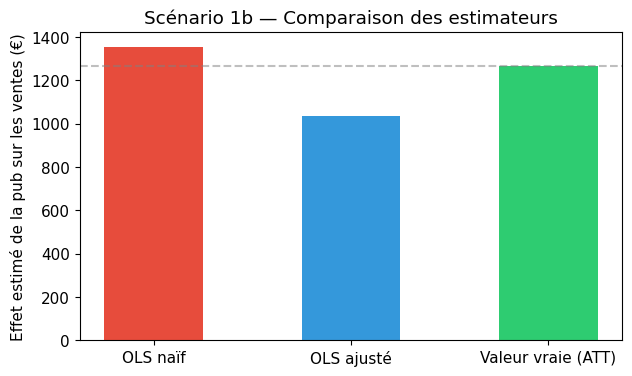

In [19]:
# ─────────────────────────────────────────────
# Figure bar chart — Scénario 1b
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 4))
labels_1b = ['OLS naïf', 'OLS ajusté', 'Valeur vraie (ATT)']
values_1b = [coef_naive_1b, coef_adj_1b, att_1b]

ax.bar(range(len(labels_1b)), values_1b, color=colors_est, width=0.5)
ax.set_xticks(range(len(labels_1b)))
ax.set_xticklabels(labels_1b)
ax.set_ylabel('Effet estimé de la pub sur les ventes (€)')
ax.set_title('Scénario 1b — Comparaison des estimateurs')
ax.axhline(y=att_1b, color='gray', linestyle='--', alpha=0.5)
fig.savefig('figures/sc1b_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Scénario 1c — Biais de sélection par saison

Le confondant `saison` détermine à la fois la probabilité de recevoir la pub (haute saison = plus de pub) et le niveau des ventes. L'assignation pub varie par mois (niveau ligne). Le modèle naïf omet les dummies de mois, rendant le biais saisonnier visible.

In [20]:
# ─────────────────────────────────────────────
# Scénario 1c — Sélection par saison
# Confondant : effet_saison_val (via mois)
# Assignation pub : niveau LIGNE (varie par mois) — différent de 1a/1b
# ─────────────────────────────────────────────

rng_sc1c = np.random.default_rng(SEED + 30)

# Assignation pub au niveau ligne (4800 lignes) — haute saison = pub plus probable
df_sc1c = base_df.copy()
haute_mask = df_sc1c['effet_saison_val'] > 0
probs_1c = np.where(haute_mask, P_PUB_HAUTE_SAISON, P_PUB_BASSE_SAISON)
df_sc1c['pub'] = rng_sc1c.binomial(1, probs_1c)
df_sc1c = compute_outcomes(df_sc1c, PARAMS, rng_sc1c)

# Calcul ATT contrefactuel — traités = lignes avec pub=1 (pas des magasins)
df_treated_1c = df_sc1c[df_sc1c['pub'] == 1].copy()
rng_cf_1c = np.random.default_rng(SEED + 31)
df_cf_1c = df_treated_1c.copy()
df_cf_1c['pub'] = 0
df_cf_1c = compute_outcomes(df_cf_1c, PARAMS, rng_cf_1c)
att_1c = (df_treated_1c['ventes'].values - df_cf_1c['ventes'].values).mean()

# OLS naïf : SANS C(mois) — pour rendre le biais saisonnier visible
model_naive_1c = smf.ols('ventes ~ pub', data=df_sc1c).fit()
# OLS ajusté : AVEC C(mois) — contrôle la saison
model_adj_1c   = smf.ols('ventes ~ pub + C(mois)', data=df_sc1c).fit()

# Export CSV
df_sc1c.to_csv('data/sc1c_selection_saison.csv', index=False)
print(f"Sc1c — Lignes pub=1 : {df_sc1c['pub'].sum()}/4800")
print(f"Sc1c — ATT: {att_1c:.1f} €  |  OLS naïf (sans mois): {model_naive_1c.params['pub']:.1f} €  |  OLS ajusté (C(mois)): {model_adj_1c.params['pub']:.1f} €")

Sc1c — Lignes pub=1 : 2587/4800
Sc1c — ATT: 1253.8 €  |  OLS naïf (sans mois): 1188.2 €  |  OLS ajusté (C(mois)): 1097.2 €


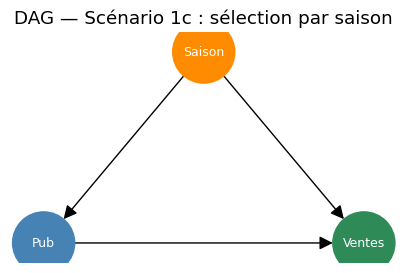

In [21]:
# ─────────────────────────────────────────────
# Figure DAG — Scénario 1c
# ─────────────────────────────────────────────

G_1c = nx.DiGraph()
G_1c.add_edges_from([
    ('Saison', 'Pub'),
    ('Saison', 'Ventes'),
    ('Pub', 'Ventes'),
])
pos_1c = {'Pub': (0, 0), 'Ventes': (2, 0), 'Saison': (1, 1)}

color_map_1c = {'Pub': 'steelblue', 'Ventes': 'seagreen', 'Saison': 'darkorange'}
node_colors_1c = [color_map_1c[n] for n in G_1c.nodes()]

fig, ax = plt.subplots(figsize=(5, 3))
nx.draw_networkx(G_1c, pos_1c, ax=ax,
                 node_color=node_colors_1c,
                 node_size=2000, font_size=9, font_color='white',
                 arrows=True, arrowsize=20)
ax.axis('off')
ax.set_title('DAG — Scénario 1c : sélection par saison')
fig.savefig('figures/sc1c_dag.png', dpi=150, bbox_inches='tight')
plt.show()

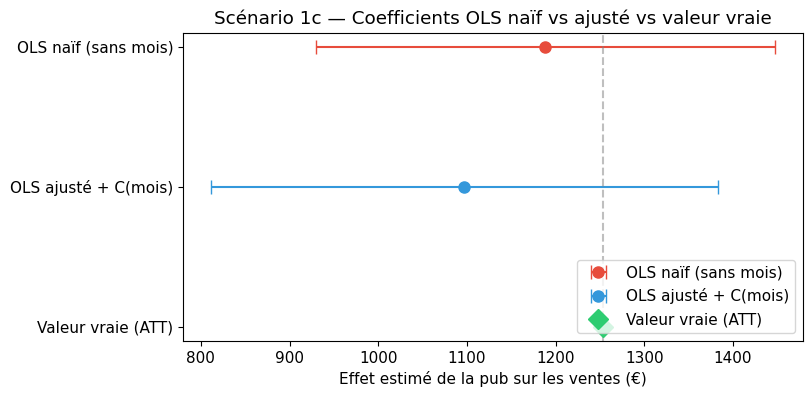

In [22]:
# ─────────────────────────────────────────────
# Figure coefficient plot — Scénario 1c
# ─────────────────────────────────────────────

coef_naive_1c = model_naive_1c.params['pub']
ci_naive_1c   = model_naive_1c.conf_int()
lower_naive_1c = ci_naive_1c.loc['pub', 0]
upper_naive_1c = ci_naive_1c.loc['pub', 1]

coef_adj_1c = model_adj_1c.params['pub']
ci_adj_1c   = model_adj_1c.conf_int()
lower_adj_1c = ci_adj_1c.loc['pub', 0]
upper_adj_1c = ci_adj_1c.loc['pub', 1]

xerr_naive_1c = [[coef_naive_1c - lower_naive_1c], [upper_naive_1c - coef_naive_1c]]
xerr_adj_1c   = [[coef_adj_1c   - lower_adj_1c],   [upper_adj_1c   - coef_adj_1c]]

estimators_1c = ['OLS naïf (sans mois)', 'OLS ajusté + C(mois)', 'Valeur vraie (ATT)']
y_pos_1c = [2, 1, 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(coef_naive_1c, 2, xerr=xerr_naive_1c, fmt='o', capsize=5,
            color='#e74c3c', label='OLS naïf (sans mois)', markersize=8)
ax.errorbar(coef_adj_1c, 1, xerr=xerr_adj_1c, fmt='o', capsize=5,
            color='#3498db', label='OLS ajusté + C(mois)', markersize=8)
ax.errorbar(att_1c, 0, fmt='D', color='#2ecc71', label='Valeur vraie (ATT)', markersize=10)
ax.axvline(x=att_1c, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks(y_pos_1c)
ax.set_yticklabels(estimators_1c)
ax.set_xlabel('Effet estimé de la pub sur les ventes (€)')
ax.set_title('Scénario 1c — Coefficients OLS naïf vs ajusté vs valeur vraie')
ax.legend(loc='lower right')
fig.savefig('figures/sc1c_coeff.png', dpi=150, bbox_inches='tight')
plt.show()

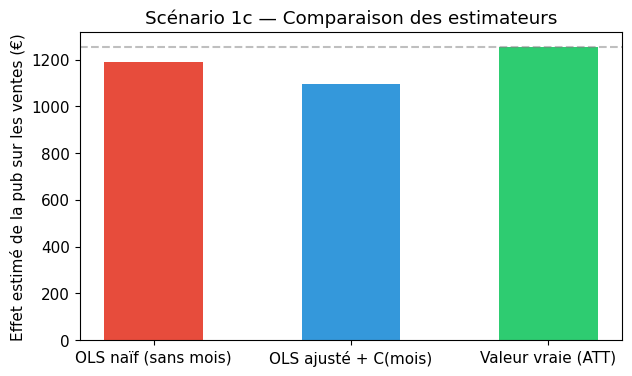

In [23]:
# ─────────────────────────────────────────────
# Figure bar chart — Scénario 1c
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 4))
labels_1c = ['OLS naïf (sans mois)', 'OLS ajusté + C(mois)', 'Valeur vraie (ATT)']
values_1c = [coef_naive_1c, coef_adj_1c, att_1c]
colors_est_1c = ['#e74c3c', '#3498db', '#2ecc71']

ax.bar(range(len(labels_1c)), values_1c, color=colors_est_1c, width=0.5)
ax.set_xticks(range(len(labels_1c)))
ax.set_xticklabels(labels_1c)
ax.set_ylabel('Effet estimé de la pub sur les ventes (€)')
ax.set_title('Scénario 1c — Comparaison des estimateurs')
ax.axhline(y=att_1c, color='gray', linestyle='--', alpha=0.5)
fig.savefig('figures/sc1c_bar.png', dpi=150, bbox_inches='tight')
plt.show()